In [82]:
!pip install snowflake-connector-python

In [83]:
from pyarrow import schema
import snowflake.connector
conn = snowflake.connector.connect(
    user="jeffreysharon5",
    password="Asrufinajeffrey05",
    account="DIMQWDK-NP52406",
    database="CREDITCARD",
    schema="PUBLIC",
    warehouse="COMPUTE_WH"
)

In [84]:
query='SELECT * FROM "CREDIT_CARD_TABLE"'

In [85]:
import pandas as pd
df=pd.read_sql(query,conn)
conn.close()
df.head()

/tmp/ipykernel_9242/2407966380.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql(query,conn)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT_PAYMENT_NEXT_MONTH
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [86]:
df.isnull().sum()

,0
ID,0
LIMIT_BAL,0
SEX,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0


In [87]:
df.shape

(30000, 25)

In [88]:
import seaborn as sns

<Axes: ylabel='AGE'>

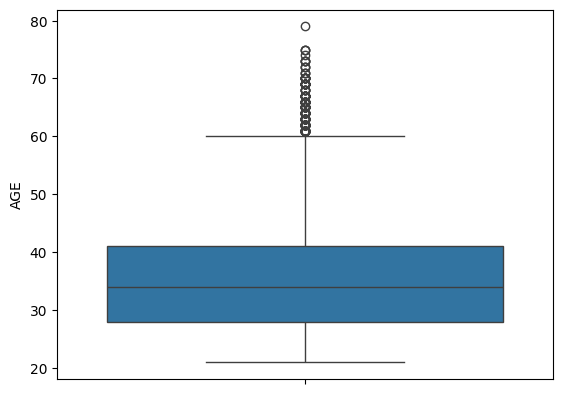

In [89]:
sns.boxplot(df['AGE'])

<Axes: ylabel='AGE'>

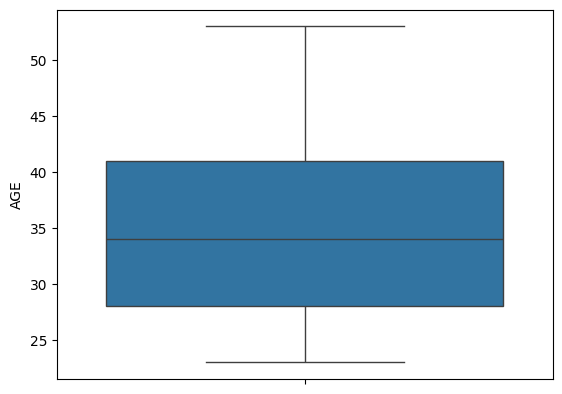

In [90]:
lower = df['AGE'].quantile(0.05)
upper = df['AGE'].quantile(0.95)

dfclip = df['AGE'].clip(lower, upper)
sns.boxplot(dfclip)

<Axes: ylabel='LIMIT_BAL'>

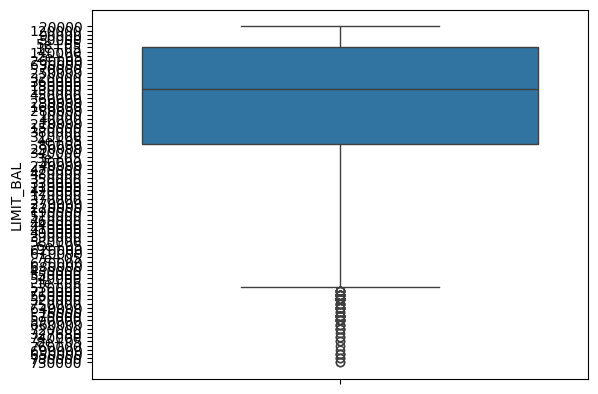

In [91]:
sns.boxplot(df['LIMIT_BAL'])

<Axes: ylabel='PAY_2'>

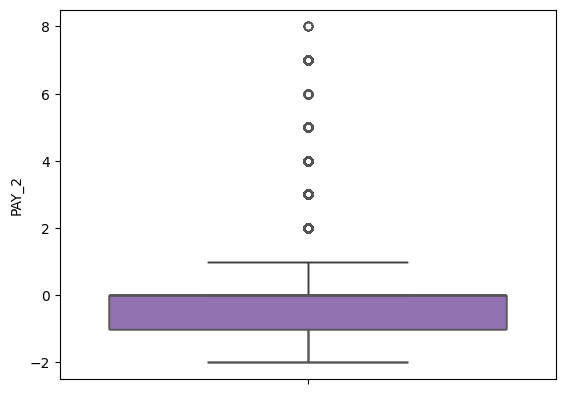

In [92]:
sns.boxplot(df['PAY_2'])
sns.boxplot(df['PAY_3'])
sns.boxplot(df['PAY_4'])
sns.boxplot(df['PAY_5'])
sns.boxplot(df['PAY_6'])

<Axes: ylabel='PAY_0'>

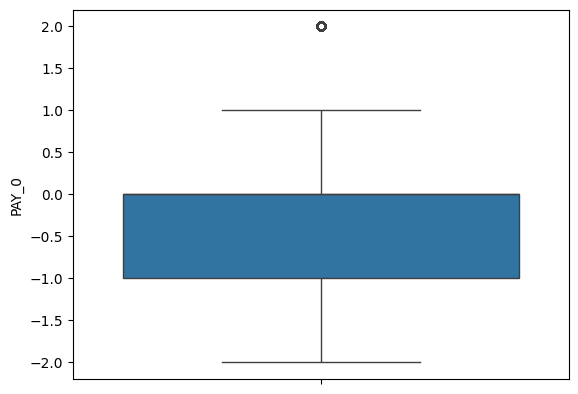

In [93]:
lower = df['PAY_0'].quantile(0.95)
upper = df['PAY_0'].quantile(0.05)

dfclippay = df['PAY_0'].clip(lower, upper)
sns.boxplot(dfclippay)

In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   ID                          30000 non-null  int64 
 1   LIMIT_BAL                   30000 non-null  object
 2   SEX                         30000 non-null  int64 
 3   EDUCATION                   30000 non-null  int64 
 4   MARRIAGE                    30000 non-null  int64 
 5   AGE                         30000 non-null  int64 
 6   PAY_0                       30000 non-null  int64 
 7   PAY_2                       30000 non-null  int64 
 8   PAY_3                       30000 non-null  int64 
 9   PAY_4                       30000 non-null  int64 
 10  PAY_5                       30000 non-null  int64 
 11  PAY_6                       30000 non-null  int64 
 12  BILL_AMT1                   30000 non-null  int64 
 13  BILL_AMT2                   30000 non-null  ob

In [95]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
for column in df.columns:
    if df[column].dtype == "object":
        df[column] = label_encoder.fit_transform(df[column])

<Axes: ylabel='PAY_AMT1'>

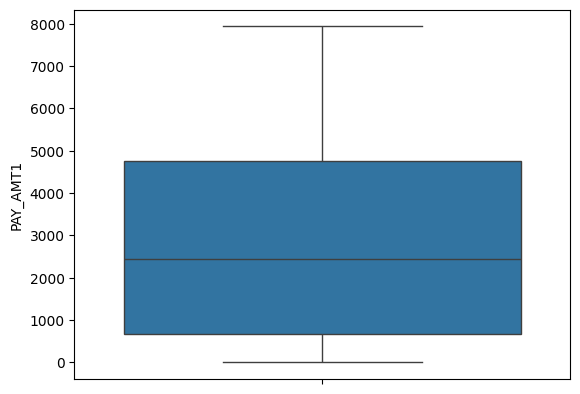

In [96]:
sns.boxplot(df['PAY_AMT1'])

In [97]:
x = df.drop("DEFAULT_PAYMENT_NEXT_MONTH", axis=1)
y = df["DEFAULT_PAYMENT_NEXT_MONTH"]

In [98]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.25,random_state=42)

In [99]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(criterion="entropy")

In [100]:
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [101]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7288


In [102]:
print(confusion_matrix(y_test, y_pred))

[[4788 1085]
 [ 949  678]]


In [103]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.82      0.82      5873
           1       0.38      0.42      0.40      1627

    accuracy                           0.73      7500
   macro avg       0.61      0.62      0.61      7500
weighted avg       0.74      0.73      0.73      7500



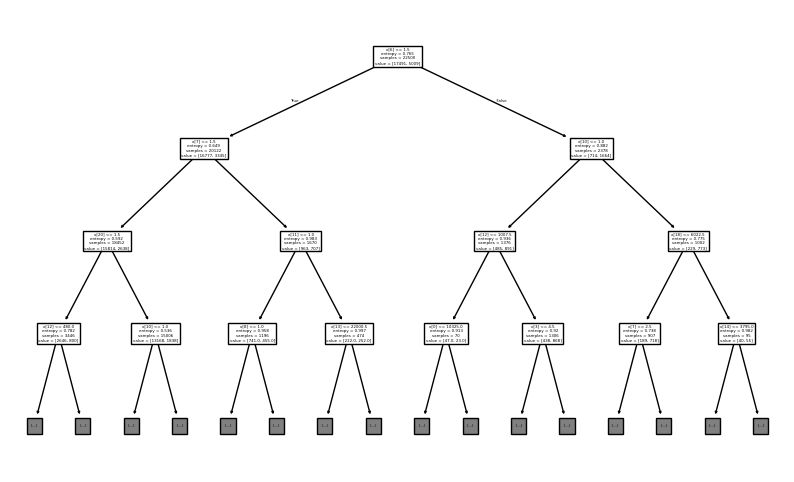

In [104]:
import matplotlib.pyplot as plt
from sklearn import tree
fig = plt.figure(figsize=(10,6))
tree.plot_tree(model,max_depth=3)
plt.show()